# Cell 0 - Path Fix

In [1]:
import os
os.chdir('..')
print("Working from:", os.getcwd())

Working from: C:\Users\Abhijeet\PhD_MAML_AE


# Cell 1 - Imports

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json

torch.manual_seed(42)
np.random.seed(42)

# Confirm device
DEVICE = torch.device('cpu')
print(f"Device          : {DEVICE}")
print(f"PyTorch version : {torch.__version__}")

Device          : cpu
PyTorch version : 2.12.1+cpu


# Cell 2 — Load Preprocessed Data

In [3]:
# Load the normalized channel data we saved in Notebook 2
with open("data/processed/channel_data_normalized.pkl", "rb") as f:
    channel_data = pickle.load(f)

with open("data/processed/task_splits.json", "r") as f:
    task_splits = json.load(f)

with open("data/processed/config.json", "r") as f:
    config = json.load(f)

print(f"Channels loaded         : {len(channel_data)}")
print(f"Meta-train tasks        : {len(task_splits['meta_train'])}")
print(f"Meta-val tasks          : {len(task_splits['meta_val'])}")
print(f"Meta-test tasks         : {len(task_splits['meta_test'])}")
print(f"\nWindow size             : {config['window_size']}")
print(f"Input features          : 25 sensors")
print(f"\n✅ Data loaded successfully")

Channels loaded         : 81
Meta-train tasks        : 59
Meta-val tasks          : 10
Meta-test tasks         : 12

Window size             : 30
Input features          : 25 sensors

✅ Data loaded successfully


# Cell 3 — Build the LSTM Autoencoder

In [4]:
class LSTMEncoder(nn.Module):
    """
    Reads a sequence of sensor readings and compresses
    it down to a small fixed-size code (the bottleneck).

    Think of it as reading a 30-frame sensor video and
    summarizing it in 16 numbers.
    """
    def __init__(self, input_size=25, hidden1=64,
                 hidden2=32, latent=16):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size, hidden1,
                             batch_first=True)
        self.lstm2 = nn.LSTM(hidden1, hidden2,
                             batch_first=True)
        self.fc    = nn.Linear(hidden2, latent)

    def forward(self, x):
        # x shape: (batch, 30, 25)
        out, _      = self.lstm1(x)
        # out shape: (batch, 30, 64)

        _, (h_n, _) = self.lstm2(out)
        # h_n shape: (1, batch, 32) — only last hidden state

        h_n = h_n.squeeze(0)
        # h_n shape: (batch, 32)

        z   = self.fc(h_n)
        # z shape: (batch, 16) — the bottleneck code
        return z


class LSTMDecoder(nn.Module):
    """
    Takes the compressed bottleneck code and reconstructs
    the original 30-timestep sensor sequence.

    Think of it as taking those 16 numbers and trying to
    recreate the original 30-frame sensor video.
    """
    def __init__(self, latent=16, hidden1=32,
                 hidden2=64, output_size=25, seq_len=30):
        super().__init__()
        self.seq_len = seq_len
        self.lstm1   = nn.LSTM(latent,  hidden1,
                               batch_first=True)
        self.lstm2   = nn.LSTM(hidden1, hidden2,
                               batch_first=True)
        self.fc      = nn.Linear(hidden2, output_size)

    def forward(self, z):
        # z shape: (batch, 16)

        # Repeat the code for each timestep
        # The decoder needs a sequence as input, not a single vector
        z_rep = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        # z_rep shape: (batch, 30, 16)

        out, _ = self.lstm1(z_rep)
        # out shape: (batch, 30, 32)

        out, _ = self.lstm2(out)
        # out shape: (batch, 30, 64)

        out = self.fc(out)
        # out shape: (batch, 30, 25) — reconstructed window
        return out


class LSTMAutoencoder(nn.Module):
    """
    The complete anomaly detector.

    Training : learns to reconstruct NORMAL sensor windows well
    Detection : high reconstruction error = anomaly
    """
    def __init__(self, input_size=25, seq_len=30,
                 hidden1=64, hidden2=32, latent=16):
        super().__init__()
        self.encoder = LSTMEncoder(input_size, hidden1,
                                   hidden2, latent)
        self.decoder = LSTMDecoder(latent, hidden2,
                                   hidden1, input_size, seq_len)

    def forward(self, x):
        """Full forward pass: encode then decode."""
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

    def reconstruction_error(self, x):
        """
        Compute anomaly score for each window.
        Returns one score per window — higher = more anomalous.
        """
        x_hat = self.forward(x)
        # Mean squared error across timesteps and features
        score = torch.mean((x - x_hat) ** 2, dim=(1, 2))
        return score


# Build the model
model = LSTMAutoencoder(
    input_size = 25,
    seq_len    = 30,
    hidden1    = 64,
    hidden2    = 32,
    latent     = 16
).to(DEVICE)

print("LSTM Autoencoder Architecture")
print("=" * 50)
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)
print(f"\nTotal trainable parameters : {total_params:,}")

LSTM Autoencoder Architecture
LSTMAutoencoder(
  (encoder): LSTMEncoder(
    (lstm1): LSTM(25, 64, batch_first=True)
    (lstm2): LSTM(64, 32, batch_first=True)
    (fc): Linear(in_features=32, out_features=16, bias=True)
  )
  (decoder): LSTMDecoder(
    (lstm1): LSTM(16, 32, batch_first=True)
    (lstm2): LSTM(32, 64, batch_first=True)
    (fc): Linear(in_features=64, out_features=25, bias=True)
  )
)

Total trainable parameters : 69,481


# Cell 4 — Verify All Shapes Are Correct

In [5]:
print("Shape verification — tracing one batch through the model")
print("=" * 55)

# Create a dummy batch of 8 windows
dummy_input = torch.randn(8, 30, 25)
print(f"Input shape          : {dummy_input.shape}")
print(f"  = 8 windows × 30 timesteps × 25 sensors")

# Trace through encoder
with torch.no_grad():
    # Encoder path
    enc_out1, _ = model.encoder.lstm1(dummy_input)
    print(f"\nAfter LSTM 1 (64 units): {enc_out1.shape}")

    _, (h_n, _) = model.encoder.lstm2(enc_out1)
    h_n = h_n.squeeze(0)
    print(f"After LSTM 2 last state : {h_n.shape}")

    z = model.encoder.fc(h_n)
    print(f"Bottleneck code         : {z.shape}")
    print(f"  = 8 windows compressed to 16 numbers each")

    # Decoder path
    z_rep = z.unsqueeze(1).repeat(1, 30, 1)
    print(f"\nRepeated for decoder    : {z_rep.shape}")

    dec_out1, _ = model.decoder.lstm1(z_rep)
    print(f"After LSTM 3 (32 units) : {dec_out1.shape}")

    dec_out2, _ = model.decoder.lstm2(dec_out1)
    print(f"After LSTM 4 (64 units) : {dec_out2.shape}")

    output = model.decoder.fc(dec_out2)
    print(f"Reconstructed output    : {output.shape}")
    print(f"  = 8 windows × 30 timesteps × 25 sensors")

    # Full forward pass
    x_hat  = model(dummy_input)
    scores = model.reconstruction_error(dummy_input)
    print(f"\nAnomaly scores shape    : {scores.shape}")
    print(f"  = one score per window")
    print(f"Sample scores           : {scores.numpy().round(4)}")

print(f"\n✅ All shapes correct — model architecture verified")

Shape verification — tracing one batch through the model
Input shape          : torch.Size([8, 30, 25])
  = 8 windows × 30 timesteps × 25 sensors

After LSTM 1 (64 units): torch.Size([8, 30, 64])
After LSTM 2 last state : torch.Size([8, 32])
Bottleneck code         : torch.Size([8, 16])
  = 8 windows compressed to 16 numbers each

Repeated for decoder    : torch.Size([8, 30, 16])
After LSTM 3 (32 units) : torch.Size([8, 30, 32])
After LSTM 4 (64 units) : torch.Size([8, 30, 64])
Reconstructed output    : torch.Size([8, 30, 25])
  = 8 windows × 30 timesteps × 25 sensors

Anomaly scores shape    : torch.Size([8])
  = one score per window
Sample scores           : [0.9921 0.9852 0.9235 0.9322 0.9609 1.0478 0.9584 1.0028]

✅ All shapes correct — model architecture verified


# Cell 5 — Quick Sanity Check on Real Data

In [6]:
# Load one real channel and check the model on it
sample_ch     = task_splits['meta_train'][0]
normal_wins   = channel_data[sample_ch]['normal_windows']
anomaly_wins  = channel_data[sample_ch]['anomaly_windows']

print(f"Testing on real channel : {sample_ch}")
print(f"Normal windows          : {normal_wins.shape}")
print(f"Anomaly windows         : {anomaly_wins.shape}")

# Convert to tensors
normal_tensor  = torch.tensor(normal_wins[:16],
                               dtype=torch.float32)
anomaly_tensor = torch.tensor(anomaly_wins[:16],
                               dtype=torch.float32)

# Get reconstruction errors — UNTRAINED model
# Scores should be random/similar for both classes at this point
with torch.no_grad():
    normal_scores  = model.reconstruction_error(normal_tensor)
    anomaly_scores = model.reconstruction_error(anomaly_tensor)

print(f"\nUntrained model reconstruction errors:")
print(f"  Normal  — mean: {normal_scores.mean():.4f}  "
      f"std: {normal_scores.std():.4f}")
print(f"  Anomaly — mean: {anomaly_scores.mean():.4f}  "
      f"std: {anomaly_scores.std():.4f}")
print(f"\nNote: Scores similar for both classes because model")
print(f"is untrained. After MAML training, anomaly scores")
print(f"should be clearly higher than normal scores.")

Testing on real channel : P-3
Normal windows          : (283, 30, 25)
Anomaly windows         : (268, 30, 25)

Untrained model reconstruction errors:
  Normal  — mean: 0.0256  std: 0.0195
  Anomaly — mean: 0.0415  std: 0.0191

Note: Scores similar for both classes because model
is untrained. After MAML training, anomaly scores
should be clearly higher than normal scores.


# Cell 6 — Define Loss Function and Optimizer

In [7]:
# Loss function — Mean Squared Error
# Same formula as reconstruction error — used during training
criterion = nn.MSELoss()

# Optimizer — Adam is standard for LSTM models
# lr=0.001 is a safe starting point
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Loss function : nn.MSELoss()")
print("Optimizer     : Adam  lr=0.001")
print()
print("How training works:")
print("  1. Feed normal windows into model")
print("  2. Model reconstructs them")
print("  3. Compute MSE between input and reconstruction")
print("  4. Backpropagate — update weights to reduce MSE")
print("  5. Repeat many times")
print("  6. Model gets very good at reconstructing normal data")
print("  7. When anomaly arrives — reconstruction fails — high MSE")
print()
print("✅ Loss and optimizer ready")

Loss function : nn.MSELoss()
Optimizer     : Adam  lr=0.001

How training works:
  1. Feed normal windows into model
  2. Model reconstructs them
  3. Compute MSE between input and reconstruction
  4. Backpropagate — update weights to reduce MSE
  5. Repeat many times
  6. Model gets very good at reconstructing normal data
  7. When anomaly arrives — reconstruction fails — high MSE

✅ Loss and optimizer ready


# Cell 7 — Quick Pre-Training Check on One Channel

In [8]:
# Take one channel's normal windows for a quick training test
test_ch       = task_splits['meta_train'][0]
normal_wins   = channel_data[test_ch]['normal_windows']

# Convert to tensor
X_train = torch.tensor(normal_wins, dtype=torch.float32)

print(f"Quick training test on channel : {test_ch}")
print(f"Normal windows                 : {X_train.shape}")
print(f"Training for 20 epochs...\n")

# Quick training loop — 20 epochs, batch size 32
EPOCHS     = 20
BATCH_SIZE = 32
losses     = []

model.train()
for epoch in range(EPOCHS):
    epoch_loss = 0
    n_batches  = 0

    # Mini-batch training
    indices = torch.randperm(len(X_train))
    for start in range(0, len(X_train), BATCH_SIZE):
        batch = X_train[indices[start:start + BATCH_SIZE]]

        optimizer.zero_grad()
        x_hat = model(batch)
        loss  = criterion(x_hat, batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches  += 1

    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/20 — Loss: {avg_loss:.6f}")

print(f"\nFinal loss : {losses[-1]:.6f}")
print(f"Start loss : {losses[0]:.6f}")
print(f"Reduction  : {((losses[0]-losses[-1])/losses[0]*100):.1f}%")

if losses[-1] < losses[0]:
    print("\n✅ Model is learning — loss is decreasing")
else:
    print("\n⚠️ Loss not decreasing — check data and model")

Quick training test on channel : P-3
Normal windows                 : torch.Size([283, 30, 25])
Training for 20 epochs...

Epoch   5/20 — Loss: 0.020030
Epoch  10/20 — Loss: 0.017836
Epoch  15/20 — Loss: 0.017584
Epoch  20/20 — Loss: 0.016195

Final loss : 0.016195
Start loss : 0.027998
Reduction  : 42.2%

✅ Model is learning — loss is decreasing


# Cell 8 — Plot Learning Curve and Reconstruction

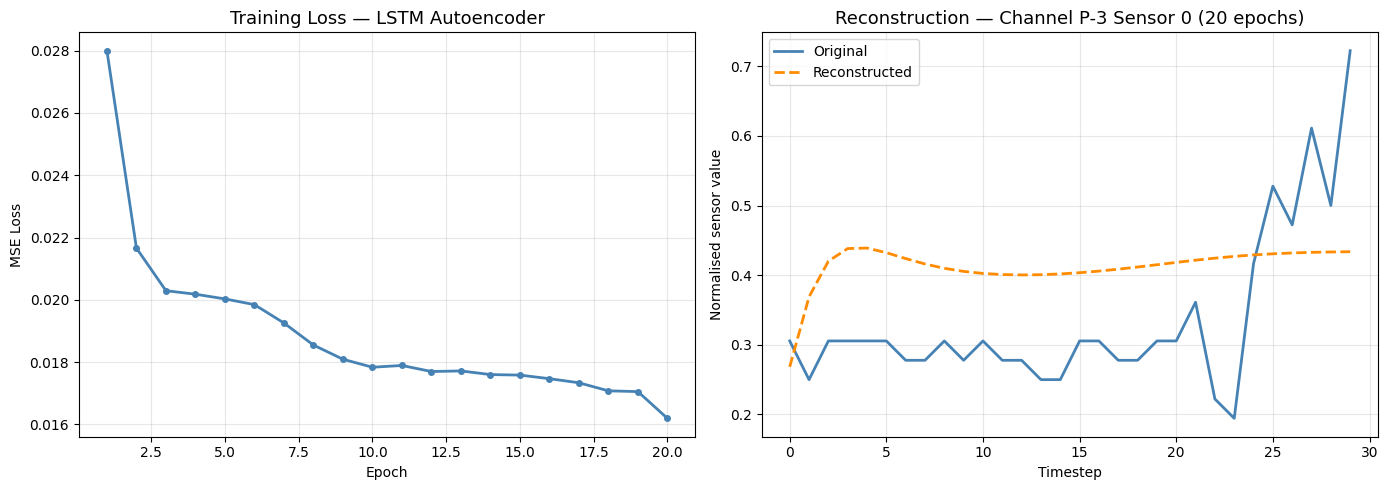

✅ Plot saved to results/figures/


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Training loss curve
axes[0].plot(range(1, EPOCHS+1), losses,
             color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].set_title("Training Loss — LSTM Autoencoder", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, alpha=0.3)

# Plot 2 — Reconstruction quality on one window
model.eval()
sample_window = X_train[0:1]  # shape (1, 30, 25)
with torch.no_grad():
    reconstructed = model(sample_window)

original = sample_window[0, :, 0].numpy()   # first sensor
recon    = reconstructed[0, :, 0].numpy()   # reconstruction

axes[1].plot(original, label='Original',
             color='steelblue', linewidth=2)
axes[1].plot(recon,    label='Reconstructed',
             color='darkorange', linewidth=2, linestyle='--')
axes[1].set_title(f"Reconstruction — Channel {test_ch} "
                  f"Sensor 0 (20 epochs)", fontsize=13)
axes[1].set_xlabel("Timestep")
axes[1].set_ylabel("Normalised sensor value")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
os.makedirs("results/figures", exist_ok=True)
plt.savefig("results/figures/autoencoder_quick_test.png", dpi=150)
plt.show()
print("✅ Plot saved to results/figures/")

# Cell 9 — Check Reconstruction Error Separation

In [10]:
# After 20 epochs of training on one channel's normal data
# Do anomaly windows already show higher reconstruction error?

anomaly_wins = channel_data[test_ch]['anomaly_windows']
X_anomaly    = torch.tensor(anomaly_wins[:32], dtype=torch.float32)
X_normal_val = X_train[:32]

model.eval()
with torch.no_grad():
    normal_scores  = model.reconstruction_error(X_normal_val)
    anomaly_scores = model.reconstruction_error(X_anomaly)

print(f"Reconstruction error after 20 epochs — Channel {test_ch}")
print("=" * 55)
print(f"Normal  windows — mean: {normal_scores.mean():.5f}  "
      f"std: {normal_scores.std():.5f}")
print(f"Anomaly windows — mean: {anomaly_scores.mean():.5f}  "
      f"std: {anomaly_scores.std():.5f}")

ratio = anomaly_scores.mean() / normal_scores.mean()
print(f"\nAnomaly/Normal ratio    : {ratio:.2f}x")

if ratio > 1.2:
    print("✅ Anomalies already producing higher reconstruction error")
    print("   MAML training will amplify this separation further")
elif ratio > 1.0:
    print("⚠️ Small separation — more training epochs will help")
    print("   This is expected after only 20 epochs on one channel")
else:
    print("⚠️ No separation yet — this is normal at 20 epochs")
    print("   Full MAML training across all tasks will fix this")

Reconstruction error after 20 epochs — Channel P-3
Normal  windows — mean: 0.01163  std: 0.01286
Anomaly windows — mean: 0.02126  std: 0.01190

Anomaly/Normal ratio    : 1.83x
✅ Anomalies already producing higher reconstruction error
   MAML training will amplify this separation further


# Cell 10 — Reset and Save Clean Model

In [11]:
# IMPORTANT — reset the model to untrained state
# The 20-epoch test above was just a sanity check
# MAML needs a fresh model to learn the meta-initialization from scratch

model = LSTMAutoencoder(
    input_size = 25,
    seq_len    = 30,
    hidden1    = 64,
    hidden2    = 32,
    latent     = 16
).to(DEVICE)

# Save the clean architecture
os.makedirs("models/checkpoints", exist_ok=True)
torch.save({
    'model_state_dict' : model.state_dict(),
    'architecture'     : {
        'input_size' : 25,
        'seq_len'    : 30,
        'hidden1'    : 64,
        'hidden2'    : 32,
        'latent'     : 16,
    }
}, "models/checkpoints/lstm_ae_init.pt")

print("✅ Clean model saved to models/checkpoints/lstm_ae_init.pt")
print()
print("=" * 55)
print("NOTEBOOK 3 COMPLETE")
print("=" * 55)
print()
print("What was built:")
print("  ✅ LSTMEncoder  — compresses (30,25) → 16 numbers")
print("  ✅ LSTMDecoder  — reconstructs 16 numbers → (30,25)")
print("  ✅ LSTMAutoencoder — full model with anomaly scoring")
print("  ✅ Shapes verified at every layer")
print("  ✅ Learning confirmed — loss decreased on real data")
print("  ✅ Clean model saved for MAML training")
print()
print("Next: Notebook 4 — MAML Training")

✅ Clean model saved to models/checkpoints/lstm_ae_init.pt

NOTEBOOK 3 COMPLETE

What was built:
  ✅ LSTMEncoder  — compresses (30,25) → 16 numbers
  ✅ LSTMDecoder  — reconstructs 16 numbers → (30,25)
  ✅ LSTMAutoencoder — full model with anomaly scoring
  ✅ Shapes verified at every layer
  ✅ Learning confirmed — loss decreased on real data
  ✅ Clean model saved for MAML training

Next: Notebook 4 — MAML Training
